In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from google.cloud import bigquery
import warnings
warnings.filterwarnings("ignore")

# Connect to BigQuery
client = bigquery.Client(project="project-a13303d6-d497-41fa-ab8")

# Load prices from BigQuery
prices = client.query("""
    SELECT date, asset, close
    FROM `project-a13303d6-d497-41fa-ab8.market_intelligence.prices`
    ORDER BY asset, date
""").to_dataframe()

prices["date"] = pd.to_datetime(prices["date"])
print("✅ Data loaded from BigQuery!")
print(f"Shape: {prices.shape}")
print(f"\nAssets: {prices['asset'].unique()}")
print(f"Date range: {prices['date'].min().date()} to {prices['date'].max().date()}")

✅ Data loaded from BigQuery!
Shape: (3568, 3)

Assets: ['Bitcoin' 'Gold' 'Oil' 'SP500']
Date range: 2023-01-01 to 2026-03-11


In [4]:
# ============================================================
# LSTM MODEL CLASS
# ============================================================

class MarketLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super(MarketLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        return self.fc(out[:, -1, :])

def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

def train_lstm(data, epochs=50, seq_length=60):
    # Scale data
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled = scaler.fit_transform(data.reshape(-1, 1))

    # Create sequences
    X, y = create_sequences(scaled, seq_length)

    # Train/test split
    split = int(len(X) * 0.80)
    X_train = torch.FloatTensor(X[:split]).unsqueeze(2)
    X_test = torch.FloatTensor(X[split:]).unsqueeze(2)
    y_train = torch.FloatTensor(y[:split])
    y_test = torch.FloatTensor(y[split:])

    # Train model
    model = MarketLSTM()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        for i in range(0, len(X_train), 32):
            X_batch = X_train[i:i+32]
            y_batch = y_train[i:i+32]
            optimizer.zero_grad()
            loss = criterion(model(X_batch).squeeze(), y_batch)
            loss.backward()
            optimizer.step()

    # Evaluate
    model.eval()
    with torch.no_grad():
        test_pred = model(X_test).squeeze().numpy()

    test_pred = scaler.inverse_transform(test_pred.reshape(-1, 1))
    y_test_actual = scaler.inverse_transform(y_test.numpy().reshape(-1, 1))

    mape = np.mean(np.abs((y_test_actual - test_pred) / y_test_actual)) * 100

    return model, scaler, test_pred, y_test_actual, mape

print("✅ LSTM model class ready!")
print("Training on all 4 assets — this will take 5-10 minutes...")

✅ LSTM model class ready!
Training on all 4 assets — this will take 5-10 minutes...


In [5]:
# ============================================================
# TRAIN LSTM FOR ALL 4 ASSETS
# ============================================================

results = {}
models = {}
scalers = {}

for asset in ["Oil", "Gold", "SP500", "Bitcoin"]:
    print(f"Training {asset}...")
    
    # Get asset data
    asset_data = prices[prices["asset"] == asset].sort_values("date")["close"].values
    
    # Train model
    model, scaler, test_pred, y_actual, mape = train_lstm(asset_data)
    
    results[asset] = {
        "mape": round(mape, 2),
        "accuracy": round(100 - mape, 2),
        "test_pred": test_pred,
        "y_actual": y_actual
    }
    models[asset] = model
    scalers[asset] = scaler
    
    print(f"✅ {asset} — Accuracy: {100 - mape:.2f}%")

print("\n=== LSTM RESULTS SUMMARY ===")
for asset, r in results.items():
    print(f"{asset}: {r['accuracy']}% accuracy (MAPE: {r['mape']}%)")

Training Oil...
✅ Oil — Accuracy: 97.79%
Training Gold...
✅ Gold — Accuracy: 91.12%
Training SP500...
✅ SP500 — Accuracy: 98.81%
Training Bitcoin...
✅ Bitcoin — Accuracy: 96.87%

=== LSTM RESULTS SUMMARY ===
Oil: 97.79000091552734% accuracy (MAPE: 2.2100000381469727%)
Gold: 91.12000274658203% accuracy (MAPE: 8.880000114440918%)
SP500: 98.80999755859375% accuracy (MAPE: 1.190000057220459%)
Bitcoin: 96.87000274658203% accuracy (MAPE: 3.130000114440918%)


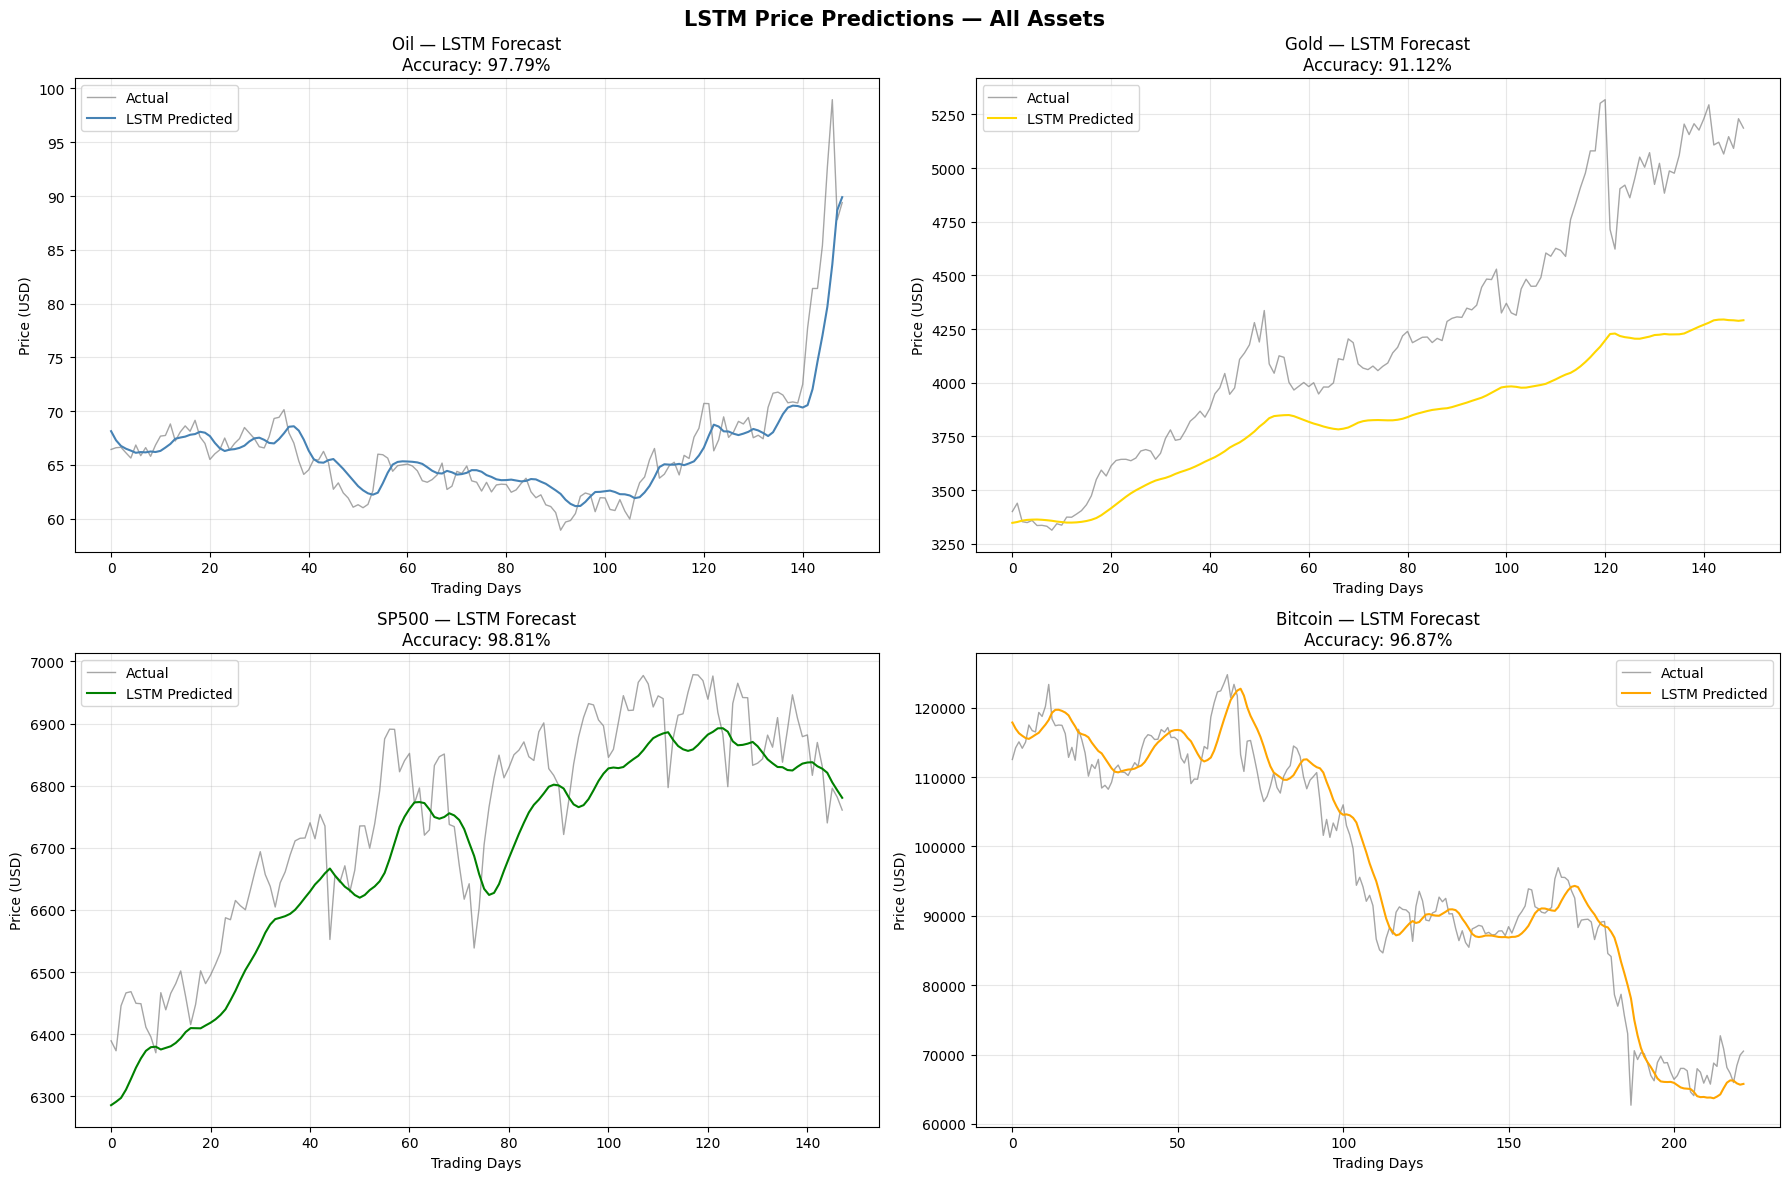

In [6]:
# ============================================================
# PLOT ALL 4 ASSET PREDICTIONS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
asset_colors = {"Oil": "steelblue", "Gold": "gold", 
                "SP500": "green", "Bitcoin": "orange"}

for idx, asset in enumerate(["Oil", "Gold", "SP500", "Bitcoin"]):
    ax = axes[idx//2, idx%2]
    color = asset_colors[asset]
    r = results[asset]
    
    ax.plot(r["y_actual"], color="gray", linewidth=1, 
            alpha=0.7, label="Actual")
    ax.plot(r["test_pred"], color=color, linewidth=1.5, 
            label=f"LSTM Predicted")
    
    ax.set_title(f"{asset} — LSTM Forecast\nAccuracy: {r['accuracy']:.2f}%", 
                 fontsize=12)
    ax.set_ylabel("Price (USD)")
    ax.set_xlabel("Trading Days")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("LSTM Price Predictions — All Assets", 
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/lstm_all_assets.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# ============================================================
# GENERATE FUTURE FORECASTS & SAVE TO BIGQUERY
# ============================================================

forecast_days = 30
all_forecasts = []

for asset in ["Oil", "Gold", "SP500", "Bitcoin"]:
    asset_data = prices[prices["asset"] == asset].sort_values("date")["close"].values
    last_date = prices[prices["asset"] == asset]["date"].max()
    
    model = models[asset]
    scaler = scalers[asset]
    
    # Scale full data
    scaled = scaler.transform(asset_data.reshape(-1, 1))
    
    # Use last 60 days as seed
    sequence = scaled[-60:].reshape(1, 60, 1)
    
    # Generate forecast
    model.eval()
    predictions = []
    current_seq = torch.FloatTensor(sequence)
    
    with torch.no_grad():
        for _ in range(forecast_days):
            pred = model(current_seq).item()
            predictions.append(pred)
            # Slide window
            new_seq = torch.cat([
                current_seq[:, 1:, :],
                torch.FloatTensor([[[pred]]])
            ], dim=1)
            current_seq = new_seq
    
    # Inverse transform
    predictions = scaler.inverse_transform(
        np.array(predictions).reshape(-1, 1)
    ).flatten()
    
    # Create forecast dates
    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        periods=forecast_days,
        freq="D"
    )
    
    for date, pred_price in zip(future_dates, predictions):
        all_forecasts.append({
            "date": date.date(),
            "asset": asset,
            "predicted_price": round(float(pred_price), 2),
            "model": "LSTM",
            "accuracy": round(results[asset]["accuracy"], 2)
        })
    
    print(f"✅ {asset} — 30 day forecast generated")
    print(f"   Current: ${asset_data[-1]:.2f} → "
          f"Forecast 30d: ${predictions[-1]:.2f}")

# Save to BigQuery
forecasts_df = pd.DataFrame(all_forecasts)

table_id = "project-a13303d6-d497-41fa-ab8.market_intelligence.predictions"
job_config = bigquery.LoadJobConfig(
    schema=[
        bigquery.SchemaField("date", "DATE"),
        bigquery.SchemaField("asset", "STRING"),
        bigquery.SchemaField("predicted_price", "FLOAT"),
        bigquery.SchemaField("model", "STRING"),
        bigquery.SchemaField("accuracy", "FLOAT"),
    ],
    write_disposition="WRITE_TRUNCATE"
)

job = client.load_table_from_dataframe(forecasts_df, table_id, job_config=job_config)
job.result()
print(f"\n✅ Forecasts saved to BigQuery!")
print(forecasts_df.groupby("asset")[["predicted_price"]].last())

✅ Oil — 30 day forecast generated
   Current: $89.39 → Forecast 30d: $69.36
✅ Gold — 30 day forecast generated
   Current: $5186.10 → Forecast 30d: $3566.24
✅ SP500 — 30 day forecast generated
   Current: $6760.72 → Forecast 30d: $6511.53
✅ Bitcoin — 30 day forecast generated
   Current: $70491.59 → Forecast 30d: $43918.54

✅ Forecasts saved to BigQuery!
         predicted_price
asset                   
Bitcoin         43918.54
Gold             3566.24
Oil                69.36
SP500            6511.53
